# Language Models (2): Feedforward Neural Language Model using PyTorch

### Prerequisite
- if you are not familiar with PyTorch: [Stanford CS224N PyTorch Tutorial](https://colab.research.google.com/drive/1Z6K6nwbb69XfuInMx7igAp-NNVj_2xc3?usp=sharing)

### Task: This practical task is open-ended. Your goal is to optimise a feedforward neural language model (LM) using a subset of MTSamples.

You are provided with:

- Data extraction and preprocessing from MTSamples
- A partially developed feedforward neural network (FFNN) language model using PyTorch
- Several code snippets/functions for using the trained LM

Currently, the performance of the LM is far from ideal (run it to check the results). You are required to:

- Adjust all possible aspects of the entire pipeline to enhance performance
- Compare your optimised model with n-gram language models or different distributed representations from NLP session 1

## Prerequisite: Google Drive Mounted Data Path
The notebook uses a data folder that is linked to one of your folders in Google Drive.

In [1]:
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# specify the folder path where the datasets reside
data_folder = '/content/drive/MyDrive/AMLH/week8-NLP2/lab/student'

Mounted at /content/drive


In [2]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# set a seed for reproducible results
torch.manual_seed(1)


## Select GPU if available
The following command will check and choose a GPU device when available:

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Select random samples from MTSamples
*This block is reused from our initial NLP practical material on word semantics.*

In [4]:
import random
import pandas as pd
import spacy

spacy_model = spacy.load('en_core_web_sm')
# read mtsamples
df_mtsamples = pd.read_csv(f'{data_folder}/mtsamples_ihi.csv')

df_mtsamples = df_mtsamples.dropna(subset=['transcription'])


# get some random files
def sampling_by_category(category, df, n_files):
    seed = 6
    cat_files = df[df['medical_specialty'].str.strip() == category]
    sampled = cat_files.sample(n=min(cat_files.shape[0], n_files), random_state=seed)
    print('pick %s rows of %s (total=%s)' % (len(sampled), category, cat_files.shape[0]))
    return sampled.index.to_list()

n_docs_per_cat = 150
indices = []
categories = ['Surgery', 'Cardiovascular / Pulmonary', 'Radiology', 'Discharge Summary']
for cat in categories:
    indices += sampling_by_category(cat, df_mtsamples, n_docs_per_cat)

df_sampled = df_mtsamples.loc[indices]
df_sampled.head()

pick 150 rows of Surgery (total=1088)
pick 150 rows of Cardiovascular / Pulmonary (total=371)
pick 150 rows of Radiology (total=273)
pick 108 rows of Discharge Summary (total=108)


,description,medical_specialty,sample_name,transcription,keywords
1026,Newborn circumcision. The penile foreskin wa...,Surgery,Circumcision - Newborn,PROCEDURE: \n\n Newborn circumcision.\n\nINDIC...,"surgery, nerve block, newborn circumcision, fo..."
1259,"C5-C6 anterior cervical discectomy, bone bank...",Surgery,Anterior Cervical Discectomy - 4,PREOPERATIVE DIAGNOSIS: \n\n Left cervical rad...,"surgery, cervical radiculopathy, anterior cerv..."
1223,Bilateral Crawford subtalar arthrodesis with ...,Surgery,Arthrodesis,PREOPERATIVE DIAGNOSIS: \n\n Congenital myoton...,"surgery, myotonic muscular dystrophy, muscular..."
376,Revision rhinoplasty and left conchal cartila...,Surgery,Revision Rhinoplasty.,"PREOPERATIVE DIAGNOSIS: \n\n Nasal deformity, ...","surgery, nasal deformity, rhinoplasty, conchal..."
664,Arthroscopy of the left knee with medial meni...,Surgery,Knee Arthroscopy & Medial Meniscoplasty,PREOPERATIVE DIAGNOSIS: \n\n Internal derangem...,"surgery, arthroscopy, meniscoplasty, derangeme..."


## Generate training data from sampled MTSamples
- Padding the original sentence at both sides using a special token `<pad>`
- Generate a dictionary `word_to_ix` to map a word (token) to an integer number
- Also create a dictionary `ix_to_word` to map a number to token (for later text generation)

In [5]:
# define the context window size (a sequence will be of the length: word_window + 1)
word_window = 2

def load_corpus(df_sampled):
    for _, r in df_sampled.iterrows():
        doc = spacy_model(str(r['transcription']))
        for s in doc.sents:
            yield s

def prepare_sequence(seq, to_ix):
    idxs = [to_ix[w] for w in seq]
    return torch.tensor(idxs, dtype=torch.long)

def padding_token_sentence(sent, win_size, pad_token='<pad>'):
    tokens = [t.lemma_.lower() for t in sent if not (t.is_stop or t.is_punct) and t.is_alpha]
    tokens = [pad_token] * win_size + tokens + [pad_token] * win_size
    return tokens

training_data = []
word_to_ix = {}
word_to_ix['<pad>'] = len(word_to_ix)
word_to_ix['<unk>'] = len(word_to_ix)

# For each words-list (sentence) in each tuple of training_data
for sent in load_corpus(df_sampled):
    tokens = padding_token_sentence(sent, word_window)
    for i in range(0, len(tokens) - word_window):
        training_data.append((tokens[i:i+word_window], [tokens[i+word_window]]))
    for word in tokens:
        if word not in word_to_ix:  # word has not been assigned an index yet
            word_to_ix[word] = len(word_to_ix)  # Assign each word with a unique index

print('vocabulary size', len(word_to_ix))

ix_to_word = [word for ind, word in enumerate(word_to_ix)]
print('index to word mapping generated')

print('training data size', len(training_data))

print('the first sample', training_data[0])

vocabulary size 8929
index to word mapping generated
training data size 168383
the first sample (['<pad>', '<pad>'], ['procedure'])


## Construct the feedforward NN model

In [6]:
from tqdm import tqdm

class FFLM(nn.Module):
  def __init__(self, vocab_size, emb_dim, hid_dim, context_size, dropout=0.5):
    # Call parent's __init__ first
    super(FFLM, self).__init__()

    # Store arguments
    self.vocab_size = vocab_size
    self.emb_dim = emb_dim
    self.hid_dim = hid_dim
    self.context_size = context_size

    # Create the loss, don't sum or average, we'll take care of it
    # in the training loop for logging purposes
    self.loss = nn.CrossEntropyLoss(reduction='none')

    # Create the non-linearity
    self.nonlin = torch.nn.Tanh()

    # Dropout regularizer
    self.drop = nn.Dropout(p=dropout)

    # Compute the dimension of the context vector
    self.context_dim = self.context_size * self.emb_dim

    # Create the embedding layer (i.e. lookup table tokens->vectors)
    self.emb = nn.Embedding(
        num_embeddings=self.vocab_size, embedding_dim=self.emb_dim,
        padding_idx=0)

    self.ff_ctx = nn.Linear(self.context_dim, self.hid_dim)

    # Output layer mapping from the output of `ff_ctx` to vocabulary size
    self.out = nn.Linear(self.hid_dim, self.vocab_size)

  def forward(self, x):
    """Forward-pass of the module."""
    # Shape of x is (batch_size, context_size)

    # Get the embeddings for the token indices in `x`
    embs = self.emb(x)

    # Concatenate the embeddings to form the context vector
    ctx = embs.view(embs.shape[0], -1)

    # apply ff_ctx -> non-lin -> dropout -> output layer
    ctx = self.drop(self.nonlin(self.ff_ctx(ctx)))
    logits = self.out(ctx)
    return logits

  def train_model(self, optimizer, loader, n_epochs=5):
    """Trains the model."""

    for eidx in range(1, n_epochs + 1):

      epoch_loss = 0
      epoch_items = 0

      # To ensure the dropout is "turned on" while training
      # (good practice to include in your projects even if it is not used)
      self.train()

      for i, (batch_inputs, batch_labels) in enumerate(tqdm(loader)):

          # Push batch to device (GPU if available)
          batch_inputs = batch_inputs.to(device=device)
          batch_labels = batch_labels.to(device=device)

          # Clear the gradients
          optimizer.zero_grad()
          # Run a forward pass
          outputs = self.forward(batch_inputs)
          # Compute the batch loss
          batch_loss = self.loss(outputs, batch_labels.squeeze(-1))
          # Calculate the gradients
          batch_loss.mean().backward()
          # Update the parameteres
          optimizer.step()
          # Sum the loss for reporting, along with the denominator
          epoch_loss += batch_loss.detach().sum()
          epoch_items += batch_loss.numel()

      loss_per_token = epoch_loss / epoch_items
      print(f'[Epoch {eidx:<3}] loss: {loss_per_token:6.2f}')

## Load Data
- Use PyTorch `DataLoader` for batch data loading
- In each batch:
    - Convert `history` tokens into numbers
    - Convert `w` (target) token into a number

In [7]:
from torch.utils.data import DataLoader
from functools import partial

def convert_tokens_to_indices(sentence, word_to_ix):
    return [word_to_ix.get(token, word_to_ix["<unk>"]) for token in sentence]


def custom_collate_fn(batch, word_to_ix):
    x, y = zip(*batch)
    x = [convert_tokens_to_indices(s, word_to_ix) for s in x]
    y = [convert_tokens_to_indices(s, word_to_ix) for s in y]
    return torch.LongTensor(x), torch.LongTensor(y)


collate_fn = partial(custom_collate_fn, word_to_ix=word_to_ix)

batch_size= 64
shuffle = True
# Instantiate a DataLoader
loader = DataLoader(training_data, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)


In [8]:

# Get the first batch
first_batch = next(iter(loader))

# Print the shape of the first batch
data_batch, labels_batch = first_batch
print(f"Data batch shape: {data_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")

Data batch shape: torch.Size([64, 2])
Labels batch shape: torch.Size([64, 1])


## Initialise the model and train it

In [9]:
fflm_model = FFLM(
    len(word_to_ix),  # vocabulary size
    emb_dim=50,      # word embedding dim
    hid_dim=128,      # hidden layer dim
    context_size=2,   # C = (N-1) if you think in n-gram LM terminology
    dropout=0.4,      # dropout probability
)

# move to device
fflm_model.to(device)

# Initial learning rate for the optimizer
FFLM_INIT_LR = 0.001

# Create the optimizer
fflm_optimizer = torch.optim.Adam(fflm_model.parameters(), lr=FFLM_INIT_LR)
print(fflm_model)

fflm_model.train_model(fflm_optimizer, loader, n_epochs=15)

FFLM(
  (loss): CrossEntropyLoss()
  (nonlin): Tanh()
  (drop): Dropout(p=0.4, inplace=False)
  (emb): Embedding(8929, 50, padding_idx=0)
  (ff_ctx): Linear(in_features=100, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=8929, bias=True)
)


100%|██████████| 2631/2631 [00:05<00:00, 468.13it/s]


[Epoch 1  ] loss:   6.44


100%|██████████| 2631/2631 [00:04<00:00, 548.69it/s]


[Epoch 2  ] loss:   5.76


...

[Epoch 13 ] loss:   4.06


100%|██████████| 2631/2631 [00:05<00:00, 508.81it/s]


[Epoch 14 ] loss:   4.00


100%|██████████| 2631/2631 [00:04<00:00, 549.72it/s]

[Epoch 15 ] loss:   3.94


## Use the trained model to generate some texts

In [10]:
import random
import numpy as np

def generate_next_word(model, word_list, win_size=2, top_k=10):
    # Turn on evaluate mode. This de-activates dropout.
    model.eval()

    with torch.no_grad():
        # Convert the last 'win_size' words in 'word_list' to their corresponding indices
        inputs = convert_tokens_to_indices(word_list[-win_size:], word_to_ix)

        # Move the model to CPU
        model = model.to('cpu')

        # Get the logits (raw predictions) from the model
        logits = model(torch.LongTensor([inputs]))

        # Apply softmax to get probabilities
        output_probas = nn.Softmax(dim=-1)(logits)

        # Sample from the top k values in the softmax output
        top_k_probs, top_k_indices = torch.topk(output_probas, top_k, dim=-1)
        top_k_probs = top_k_probs.squeeze().cpu().numpy()
        top_k_indices = top_k_indices.squeeze().cpu().numpy()


        # Normalize the probabilities
        top_k_probs /= top_k_probs.sum()


        # Sample a word index from the top k probabilities
        sampled_idx = np.random.choice(top_k_indices, p=top_k_probs)

        return ix_to_word[sampled_idx]


def generate_text(seed, model, stop_token='<pad>', win_size=2):
    word_list = seed.split()
    for _ in range(10):
        new_word = generate_next_word(model, word_list, win_size=win_size)
        if new_word != stop_token:
            word_list += [new_word]
        else:
            break
    return ' '.join(word_list)

for _ in range(10):
    # seed = '<ukn> <ukn> <ukn> <ukn>'
    seed = '<pad> <pad> the patient'
    print(generate_text(seed, fflm_model, win_size=word_window))

<pad> <pad> the patient place prone position prepped drape sterile fashion
<pad> <pad> the patient place modify beach chair position wound
<pad> <pad> the patient preppe drape usual sterile fashion
<pad> <pad> the patient anesthetize patient
<pad> <pad> the patient
<pad> <pad> the patient preppe drape usual sterile fashion
<pad> <pad> the patient take recovery room good condition
<pad> <pad> the patient place modify beachchair position
<pad> <pad> the patient foreign body
<pad> <pad> the patient


## Visualise embeddings from the LM
- Visualise functions below are copied from a previous practical

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def vis(data, title, ax):
    pca = PCA(n_components=2)
    pca_result= pca.fit_transform(data)
    transformed = pd.DataFrame(pca_result, columns=['d1', 'd2'])
    sns.scatterplot(
        x="d1", y="d2",
        data=transformed,
        legend="full",
        color='g',
        ax=ax
    )
    for i in range(transformed.shape[0]):
        ax.text(x=transformed.d1[i],y=transformed.d2[i],s=data.index[i])
    ax.set_title(title)


given_terms = ['diabetes', 'mellitus', 'hemorrhagic',
               'fibrillation', 'atrial',
               'stroke', 'anticoagulation']

### Retrieve the embeddings and visualise the given terms

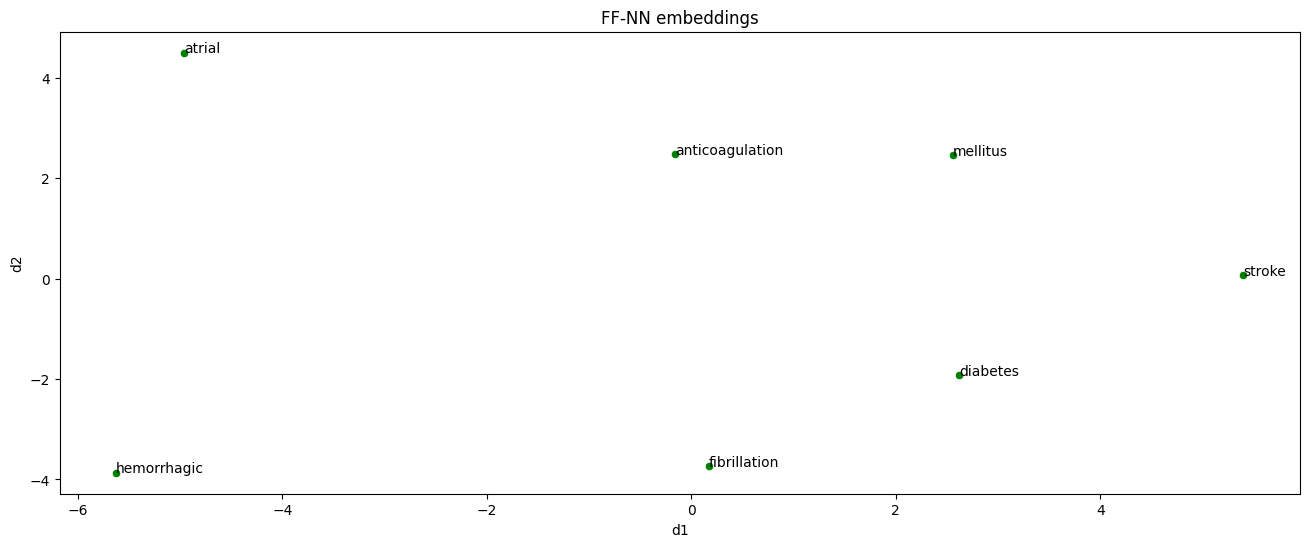

In [12]:
def get_embedding(w):
    # get the embedding of a given token - w
    # you will get an error if w not in the vocabulary.
    # Remember we have lemmatised and lowercased our words
    return fflm_model.emb.weight[word_to_ix[w]].detach().numpy()

fig, (ax1) = plt.subplots(1,1, figsize=(16,6))

w2em = {}
for w in given_terms:
    w2em[w] = get_embedding(w)[:]
ff_df = pd.DataFrame(w2em).transpose()
vis(ff_df.loc[given_terms], 'FF-NN embeddings', ax1)

## Implement the document classification task to compare different distributed representations

In [13]:
# Reference week 7 practical material for the document classification task

In [15]:
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

def do_a_vsimple_rf_classification(X, y, test_size=0.2, random_state=9):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    rfc = RandomForestClassifier(random_state=random_state)
    rfc.fit(X_train,y_train)

    rfc_predict = rfc.predict(X_test)
    return classification_report(y_test, rfc_predict)

y = [categories.index(df_mtsamples.loc[d, 'medical_specialty'].strip()) for d in df_sampled.index]

def process_transcription(transcription):

    doc = spacy_model(transcription)
    tokens = [t.lemma_.lower() for t in doc if not (t.is_stop or t.is_punct) and t.is_alpha]
    embeddings = [get_embedding(w) for w in tokens]
    if embeddings:
        return sum(embeddings) / len(embeddings)
    else:
        print(transcription)
        return None

df_sampled['processed_transcription'] = df_sampled['transcription'].apply(process_transcription)
X = list(df_sampled['processed_transcription'])

print(do_a_vsimple_rf_classification(X, y))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        35
           1       0.62      0.53      0.57        30
           2       0.87      0.87      0.87        31
           3       0.67      0.75      0.71        16

    accuracy                           0.76       112
   macro avg       0.74      0.75      0.75       112
weighted avg       0.75      0.76      0.76       112

